Este notebook realiza a extração de características (features) a partir das URLs presentes no dataset. As features geradas representam aspectos estruturais, léxicos e heurísticos frequentemente associados a ataques de phishing.

#### Importando bibliotecas e carregando os dados

In [2]:
# Importando as bibliotecas
import sys
import os

sys.path.append(
    os.path.abspath("..")
)

import matplotlib.pyplot as plt
import seaborn as sns
from features.feature_extractor_v2 import extract_features
import pandas as pd

In [4]:
# Carregando os dados
df_url = pd.read_csv("../datasets/interim/df_built.csv")      

In [5]:
# Visualizando os dados
df_url.head()

,url,label,source
0,https://start-ledggee-cdn.teachable.com/p/home,1,phishingdb
1,http://43.153.192.86/v3/signin/identifier?dsh=...,1,phishingdb
2,http://63179679.satgrjtxcvdv.org.cn/amagc,1,phishingdb
3,http://amber-kh.com/dollarman/ujhost/Account%2...,1,phishingdb
4,http://207.154.253.64/banks/CIBC/4fdb6096796be...,1,phishingdb


#### Feature Extraction (`feature_extractor_v2.py`)

In [6]:
# Aplicando a função
features_df = pd.DataFrame(
    [extract_features(url) for url in df_url["url"]]
)

In [7]:
features_df.head()

,NumDots,SubdomainLevel,PathLevel,UrlLength,NumDash,NumDashInHostname,AtSymbol,TildeSymbol,NumUnderscore,NumPercent,...,Has_security,Has_support,SuspiciousTLD,ManySubdomains,KnownBrandInURL,SpecialCharRatio,LongURL,VeryLongURL,UrlEntropy,FreeHosting
0,2,1,2,46,2,2,0,0,0,0,...,0,0,0,0,0,0.043478,0,0,4.058691,0
1,13,2,3,432,2,0,0,0,8,0,...,0,0,0,1,1,0.023148,1,1,5.703598,0
2,3,2,1,41,0,0,0,0,0,0,...,0,0,0,1,0,0.000000,0,0,4.338663,0
3,2,0,6,98,1,1,0,0,0,3,...,0,1,0,0,0,0.040816,1,0,4.633045,0
4,3,2,3,65,0,0,0,0,0,0,...,0,0,0,1,0,0.000000,0,0,4.512935,0


#### Consolidação do Dataset

In [8]:
# Consolidação do dataset
df_features = pd.concat(
    [
        df_url,
        features_df
    ],
    axis=1
)

In [9]:
features_df.shape

(115934, 48)

#### Verificações de Qualidade

In [10]:
# Tipos
features_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 115934 entries, 0 to 115933
Data columns (total 48 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   NumDots             115934 non-null  int64  
 1   SubdomainLevel      115934 non-null  int64  
 2   PathLevel           115934 non-null  int64  
 3   UrlLength           115934 non-null  int64  
 4   NumDash             115934 non-null  int64  
 5   NumDashInHostname   115934 non-null  int64  
 6   AtSymbol            115934 non-null  int64  
 7   TildeSymbol         115934 non-null  int64  
 8   NumUnderscore       115934 non-null  int64  
 9   NumPercent          115934 non-null  int64  
 10  NumQueryComponents  115934 non-null  int64  
 11  NumAmpersand        115934 non-null  int64  
 12  NumHash             115934 non-null  int64  
 13  NumNumericChars     115934 non-null  int64  
 14  PctNumericChars     115934 non-null  float64
 15  NoHttps             115934 non-null  int64  


In [11]:
# Valores Ausentes
features_df.isnull().sum()

NumDots               0
SubdomainLevel        0
PathLevel             0
UrlLength             0
NumDash               0
NumDashInHostname     0
AtSymbol              0
TildeSymbol           0
NumUnderscore         0
NumPercent            0
NumQueryComponents    0
NumAmpersand          0
NumHash               0
NumNumericChars       0
PctNumericChars       0
NoHttps               0
IpAddress             0
DomainInSubdomains    0
DomainInPaths         0
HostnameLength        0
PathLength            0
QueryLength           0
HttpsInHostname       0
HostnameHasDigit      0
HostnameDigitCount    0
NumSensitiveWords     0
DoubleSlashInPath     0
Has_login             0
Has_verify            0
Has_secure            0
Has_account           0
Has_update            0
Has_confirm           0
Has_signin            0
Has_bank              0
Has_payment           0
Has_wallet            0
Has_password          0
Has_security          0
Has_support           0
SuspiciousTLD         0
ManySubdomains  

In [12]:
df_features.describe()

,label,NumDots,SubdomainLevel,PathLevel,UrlLength,NumDash,NumDashInHostname,AtSymbol,TildeSymbol,NumUnderscore,...,Has_security,Has_support,SuspiciousTLD,ManySubdomains,KnownBrandInURL,SpecialCharRatio,LongURL,VeryLongURL,UrlEntropy,FreeHosting
count,115934.000000,115934.000000,115934.000000,115934.000000,115934.000000,115934.000000,115934.000000,115934.000000,115934.000000,115934.000000,...,115934.000000,115934.000000,115934.000000,115934.000000,115934.000000,115934.000000,115934.000000,115934.000000,115934.000000,115934.000000
mean,0.500000,2.618455,0.546621,2.883408,66.231106,1.284507,0.241775,0.016949,0.007599,0.417574,...,0.003718,0.005193,0.045466,0.152121,0.072265,0.025290,0.233745,0.091552,4.236870,0.022254
std,0.500002,3.597326,0.858883,6.597202,71.318429,2.575090,0.771647,0.129082,0.086842,1.746677,...,0.060859,0.071873,0.208324,0.359140,0.258928,0.035331,0.423214,0.288394,0.431324,0.147509
min,0.000000,1.000000,0.000000,0.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.703533,0.000000
25%,0.000000,1.000000,0.000000,1.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.965748,0.000000
50%,0.500000,2.000000,0.000000,2.000000,45.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.011111,0.000000,0.000000,4.234775,0.000000
75%,1.000000,3.000000,1.000000,3.000000,72.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.040000,0.000000,0.000000,4.495111,0.000000
max,1.000000,121.000000,35.000000,118.000000,1569.000000,87.000000,11.000000,1.000000,1.000000,38.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.331066,1.000000,1.000000,6.011721,1.000000


#### Avaliação Inicial das Features

In [13]:
feature_cols = [
    col for col in df_features.columns
    if col not in ["url", "label", "source"]
]

In [14]:
feature_summary = (
    df_features
    .groupby("label")[feature_cols]
    .mean()
    .T
)

feature_summary

label,0,1
NumDots,1.935498,3.301413
SubdomainLevel,0.008177,1.085066
PathLevel,2.503235,3.263581
UrlLength,57.695361,74.766850
NumDash,1.823469,0.745545
NumDashInHostname,0.000362,0.483189
AtSymbol,0.001415,0.032484
TildeSymbol,0.009022,0.006176
NumUnderscore,0.481153,0.353995
NumPercent,0.534960,0.130454


In [15]:
feature_importance_eda = (
    feature_summary[1] -
    feature_summary[0]
).abs()

feature_importance_eda.sort_values(
    ascending=False
)

HostnameLength        20.942295
UrlLength             17.071489
PathLength            17.048234
QueryLength            6.680749
NumNumericChars        5.910949
HostnameDigitCount     4.981110
NumDots                1.365915
NumDash                1.077924
SubdomainLevel         1.076889
DomainInPaths          0.913313
DomainInSubdomains     0.911122
PathLevel              0.760346
HostnameHasDigit       0.612090
NumDashInHostname      0.482826
NumPercent             0.404506
ManySubdomains         0.303621
NumSensitiveWords      0.244001
IpAddress              0.188918
NumUnderscore          0.127159
NumAmpersand           0.108717
SuspiciousTLD          0.090931
NoHttps                0.082995
PctNumericChars        0.077676
VeryLongURL            0.070523
Has_account            0.068919
NumQueryComponents     0.067504
Has_login              0.058361
UrlEntropy             0.052178
FreeHosting            0.044508
Has_bank               0.032208
Has_signin             0.031897
AtSymbol

In [16]:
corr_target = (
    df_features[feature_cols + ["label"]]
    .corr(numeric_only=True)["label"]
    .sort_values(key=abs, ascending=False)
)

corr_target

label                 1.000000
DomainInPaths        -0.915529
DomainInSubdomains   -0.913637
HostnameLength        0.765966
HostnameHasDigit      0.661357
SubdomainLevel        0.626915
HostnameDigitCount    0.493795
ManySubdomains        0.422708
IpAddress             0.322974
NumDashInHostname     0.312856
PctNumericChars       0.293921
SpecialCharRatio     -0.278906
SuspiciousTLD         0.218245
NumSensitiveWords     0.217623
NumDash              -0.209299
NoHttps              -0.198235
NumDots               0.189852
Has_account           0.171391
NumNumericChars       0.160701
PathLength           -0.157498
FreeHosting           0.150866
VeryLongURL           0.122269
Has_signin            0.121862
AtSymbol              0.120348
UrlLength             0.119685
Has_login             0.116995
Has_bank              0.107262
Has_secure            0.082418
QueryLength           0.070648
UrlEntropy            0.060486
PathLevel             0.057627
Has_verify            0.055836
NumPerce

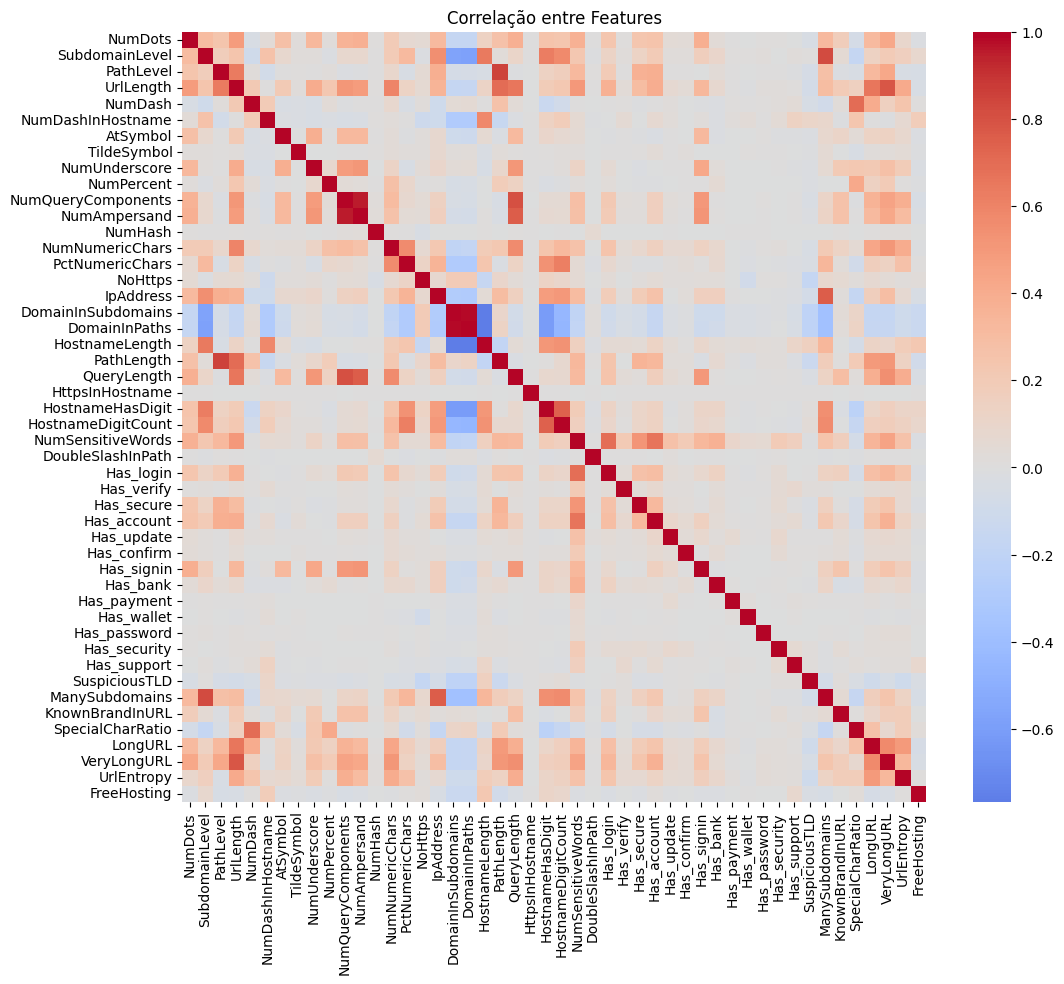

In [17]:
plt.figure(figsize=(12,10))

sns.heatmap(

    df_features[feature_cols].corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlação entre Features")
plt.show()

In [18]:
feature_cols = [
    col
    for col in df_features.columns
    if col not in ["url", "label", "source"]
]

low_variance = []

for col in feature_cols:
    if df_features[col].nunique() <= 1:
        low_variance.append(col)

low_variance

[]

In [19]:
df_features.drop(
    columns=low_variance,
    inplace=True
)

In [20]:
print(df_features.shape)

(115934, 51)


In [21]:
df_features.head()

,url,label,source,NumDots,SubdomainLevel,PathLevel,UrlLength,NumDash,NumDashInHostname,AtSymbol,...,Has_security,Has_support,SuspiciousTLD,ManySubdomains,KnownBrandInURL,SpecialCharRatio,LongURL,VeryLongURL,UrlEntropy,FreeHosting
0,https://start-ledggee-cdn.teachable.com/p/home,1,phishingdb,2,1,2,46,2,2,0,...,0,0,0,0,0,0.043478,0,0,4.058691,0
1,http://43.153.192.86/v3/signin/identifier?dsh=...,1,phishingdb,13,2,3,432,2,0,0,...,0,0,0,1,1,0.023148,1,1,5.703598,0
2,http://63179679.satgrjtxcvdv.org.cn/amagc,1,phishingdb,3,2,1,41,0,0,0,...,0,0,0,1,0,0.000000,0,0,4.338663,0
3,http://amber-kh.com/dollarman/ujhost/Account%2...,1,phishingdb,2,0,6,98,1,1,0,...,0,1,0,0,0,0.040816,1,0,4.633045,0
4,http://207.154.253.64/banks/CIBC/4fdb6096796be...,1,phishingdb,3,2,3,65,0,0,0,...,0,0,0,1,0,0.000000,0,0,4.512935,0


<Axes: xlabel='label', ylabel='SubdomainLevel'>

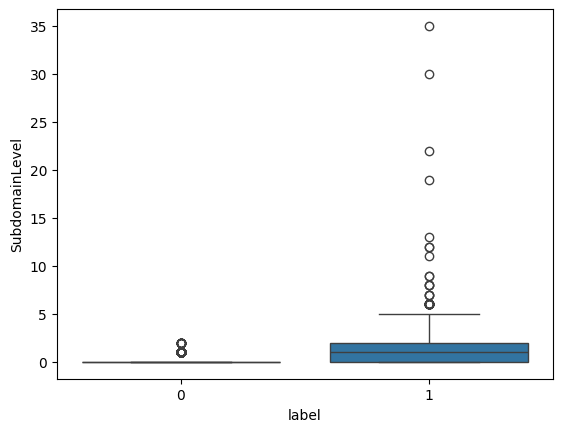

In [22]:
sns.boxplot(
    data=df_features,
    x="label",
    y="SubdomainLevel"
)

<Axes: xlabel='label', ylabel='UrlLength'>

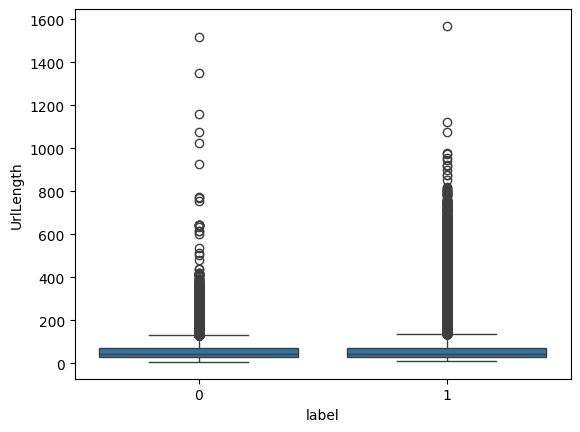

In [23]:
sns.boxplot(
    data=df_features,
    x="label",
    y="UrlLength"
)

In [24]:
df_features.to_csv(
    "../datasets/processed/df_united_v2.csv",
    index=False
)